# 02 - SSSG Forecasting Model
## CAVA Group Investment Analysis

**Objective:** Predict next-quarter Same-Restaurant Sales Growth (`sssg_pct_next`) using financial fundamentals, sentiment data, and alternative data signals.

**Key Constraint:** Only 15 quarters of data available (Q2 2022 – Q4 2025), requiring careful model selection and validation strategy.

**Approach:**
1. Feature selection & dataset preparation
2. Baseline model (naive mean predictor)
3. Linear & Ridge Regression
4. Random Forest with feature importance
5. Leave-One-Out Cross Validation (LOOCV) — appropriate for small samples
6. Model comparison & investment interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'axes.grid': False,
    'legend.fontsize': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

BASE_DIR = '/Users/zhangsu/Cava_Investment_Analysis'
print('Libraries loaded.')

Libraries loaded.


---
## Part 1: Load Data & Feature Selection

In [2]:
# ── Load master dataset ────────────────────────────────────────────────────────
master = pd.read_csv(f'{BASE_DIR}/data/processed/cava_master_quarterly.csv',
                     parse_dates=['period_end'])
master = master.sort_values('period_end').reset_index(drop=True)

print(f'Master dataset: {master.shape}')
print(f'Quarters: {master.quarter.tolist()}')

Master dataset: (15, 47)
Quarters: ['Q2 2022', 'Q3 2022', 'Q4 2022', 'Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023', 'Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024', 'Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025']


In [4]:
# ── Feature selection ──────────────────────────────────────────────────────────
# We select features based on:
# 1. Data availability (no or minimal NaN)
# 2. Economic intuition (should plausibly predict SSSG)
# 3. No data leakage (cannot use current-quarter SSSG to predict itself)

# Core fundamental features (available all 15 quarters)
fundamental_features = [
    'sssg_pct_lag1',          # Previous quarter SSSG — strongest predictor
    'sssg_pct_lag2',          # Two quarters ago SSSG — captures trend
    'sssg_rolling_3q',        # 3-quarter rolling average — smoothed trend
    'restaurant_margin_pct',  # Unit economics health
    'digital_revenue_mix_pct',# Digital penetration
    'auv_qoq',                # AUV momentum
    'margin_qoq',             # Margin momentum
    'digital_mix_qoq',        # Digital mix momentum
    'net_new_openings',       # Expansion pace
    'adj_ebitda_margin_pct',  # Overall profitability
]

# Alternative data features (partial availability)
alt_data_features = [
    'avg_search_interest',    # Google Trends (15/15)
    'search_interest_qoq',    # Google Trends momentum (15/15)
    'avg_reddit_sentiment',   # Reddit sentiment (12/15)
    'news_article_count',     # News volume proxy (15/15)
    'analyst_action_count',   # Analyst activity (15/15)
]

# Event flags
event_features = [
    'ipo_quarter',
    'sssg_beat',
    'sssg_miss',
    'guidance_cut',
]

# Target variable
target = 'sssg_pct_next'

all_features = fundamental_features + alt_data_features + event_features
print(f'Total features: {len(all_features)}')
print(f'Target: {target}')

Total features: 19
Target: sssg_pct_next


In [5]:
# ── Prepare modeling dataset ───────────────────────────────────────────────────
# Drop rows where target is NaN (last quarter has no next quarter)
# Drop rows where key features are NaN (pre-IPO quarters missing price data)

model_df = master[all_features + [target, 'quarter', 'period_end']].copy()

# Fill Reddit sentiment NaN with 0 (no signal = neutral)
# Note: we use 0 here as these are quarters with very low post volume
model_df['avg_reddit_sentiment'] = model_df['avg_reddit_sentiment'].fillna(0)

# Drop rows where target is missing
model_df = model_df.dropna(subset=[target])

# Drop rows where lag features are missing (first 2 quarters)
model_df = model_df.dropna(subset=['sssg_pct_lag1', 'sssg_pct_lag2', 'sssg_rolling_3q'])

# Fill remaining NaN with 0
model_df[all_features] = model_df[all_features].fillna(0)

print(f'Modeling dataset: {model_df.shape}')
print(f'Quarters used: {model_df.quarter.tolist()}')
print(f'\nTarget variable (sssg_pct_next) stats:')
print(model_df[target].describe())

Modeling dataset: (12, 22)
Quarters used: ['Q4 2022', 'Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023', 'Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024', 'Q1 2025', 'Q2 2025', 'Q3 2025']

Target variable (sssg_pct_next) stats:
count    12.000000
mean     11.950000
std       8.880776
min       0.500000
25%       2.250000
50%      12.750000
75%      18.125000
max      28.400000
Name: sssg_pct_next, dtype: float64


---
## Part 2: Baseline Model

Before building complex models, we establish a naive baseline:
**Predict next quarter's SSSG = mean of all historical SSSG values**

Any useful model must outperform this baseline.

In [6]:
# ── Naive baseline: predict mean SSSG ─────────────────────────────────────────
y = model_df[target].values
y_baseline = np.full_like(y, fill_value=y.mean())

baseline_mae = mean_absolute_error(y, y_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y, y_baseline))

print('=== Naive Baseline (Mean Predictor) ===')
print(f'Predicted value (always): {y.mean():.2f}%')
print(f'MAE:  {baseline_mae:.2f}%')
print(f'RMSE: {baseline_rmse:.2f}%')
print('\nAny useful model must beat these numbers.')

=== Naive Baseline (Mean Predictor) ===
Predicted value (always): 11.95%
MAE:  7.12%
RMSE: 8.50%

Any useful model must beat these numbers.


---
## Part 3: Feature Set Definitions

We test three feature sets to understand incremental value of alternative data:
- **Set A:** Fundamentals only (lag SSSG + financial metrics)
- **Set B:** Fundamentals + Alternative data (Google Trends, Reddit, News)
- **Set C:** All features including event flags

In [7]:
# ── Define feature sets ────────────────────────────────────────────────────────
feature_sets = {
    'A: Fundamentals Only': fundamental_features,
    'B: Fundamentals + Alt Data': fundamental_features + alt_data_features,
    'C: All Features': all_features,
}

X_all = model_df[all_features].values
y = model_df[target].values
quarters = model_df['quarter'].values

print('Feature sets defined:')
for name, feats in feature_sets.items():
    print(f'  {name}: {len(feats)} features')

Feature sets defined:
  A: Fundamentals Only: 10 features
  B: Fundamentals + Alt Data: 15 features
  C: All Features: 19 features


---
## Part 3.5: Improved Models — Seasonality + Feature Selection + Regularization

### Motivation

The initial model results reveal three problems that need to be addressed:

1. **Ignored seasonality:** CAVA's KPI plots show strong and consistent quarterly patterns — Q2-Q3 consistently deliver higher SSSG and margins, while Q1 (16-week fiscal quarter) and Q4 underperform. A model that ignores this structure will systematically misprice seasonal quarters.

2. **Too many features for sample size:** With only 12 usable quarters, using 10+ features leads to overfitting. The rule of thumb is ~10 observations per feature — we should use at most 3-4 features.

3. **Suboptimal regularization:** The original Ridge used alpha=1.0 arbitrarily. We should use cross-validated alpha selection.

### Three Improvements Applied Simultaneously

| Improvement | Implementation |
|-------------|---------------|
| Seasonality | Sine/cosine encoding AND one-hot quarter dummies |
| Feature reduction | 4 core features instead of 10 |
| Auto alpha tuning | RidgeCV and LassoCV via LOOCV |

### Why Lasso Instead of PCA?

PCA was considered but rejected because it destroys interpretability — principal components have no economic meaning, making it impossible to explain to the investment team *which* factors drive SSSG predictions. 

Lasso regression (L1 regularization) is preferred because it performs automatic feature selection by shrinking irrelevant coefficients to exactly zero, while retaining the interpretability of individual feature contributions. Features that survive Lasso regularization are the most robust predictors of next-quarter SSSG.

In [8]:
from sklearn.linear_model import RidgeCV, LassoCV, Lasso

# ── Add seasonality features ───────────────────────────────────────────────────
model_df['fiscal_q'] = model_df['quarter'].str.extract(r'Q(\d)').astype(int)

# Sine/cosine encoding — captures cyclical nature (Q4 and Q1 are adjacent)
# Better than one-hot for capturing periodicity
model_df['season_sin'] = np.sin(2 * np.pi * model_df['fiscal_q'] / 4)
model_df['season_cos'] = np.cos(2 * np.pi * model_df['fiscal_q'] / 4)

# One-hot encoding — alternative, more flexible approach
quarter_dummies = pd.get_dummies(
    model_df['quarter'].str.extract(r'(Q\d)')[0], prefix='fq'
)
model_df = pd.concat([model_df.reset_index(drop=True),
                      quarter_dummies.reset_index(drop=True)], axis=1)

print('Seasonality features added:')
print(model_df[['quarter', 'fiscal_q', 'season_sin', 'season_cos']].to_string())

Seasonality features added:
    quarter  fiscal_q    season_sin    season_cos
0   Q4 2022         4 -2.449294e-16  1.000000e+00
1   Q1 2023         1  1.000000e+00  6.123234e-17
2   Q2 2023         2  1.224647e-16 -1.000000e+00
3   Q3 2023         3 -1.000000e+00 -1.836970e-16
4   Q4 2023         4 -2.449294e-16  1.000000e+00
5   Q1 2024         1  1.000000e+00  6.123234e-17
6   Q2 2024         2  1.224647e-16 -1.000000e+00
7   Q3 2024         3 -1.000000e+00 -1.836970e-16
8   Q4 2024         4 -2.449294e-16  1.000000e+00
9   Q1 2025         1  1.000000e+00  6.123234e-17
10  Q2 2025         2  1.224647e-16 -1.000000e+00
11  Q3 2025         3 -1.000000e+00 -1.836970e-16


In [9]:
# ── Define improved feature sets ───────────────────────────────────────────────
# Core features: 4 most economically meaningful predictors
core_features = [
    'sssg_pct_lag1',    # Previous quarter SSSG — momentum
    'sssg_rolling_3q',  # 3-quarter rolling average — trend
    'auv_qoq',          # AUV momentum — ticket/traffic health
    'margin_qoq',       # Margin momentum — unit economics
]

feature_sets_v2 = {
    'A: Core (4 features)': core_features,
    'B: Core + Season (sin/cos)': core_features + ['season_sin', 'season_cos'],
    'C: Core + Season (one-hot)': core_features + quarter_dummies.columns.tolist(),
    'D: Original Fundamentals (10)': fundamental_features,
}

alphas_to_try = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]
loo = LeaveOneOut()

print('Feature sets v2 defined:')
for name, feats in feature_sets_v2.items():
    print(f'  {name}: {len(feats)} features')

Feature sets v2 defined:
  A: Core (4 features): 4 features
  B: Core + Season (sin/cos): 6 features
  C: Core + Season (one-hot): 8 features
  D: Original Fundamentals (10): 10 features


In [10]:
# ── Ridge with auto alpha (RidgeCV) ───────────────────────────────────────────
print('=== Ridge Regression with RidgeCV Alpha Selection ===')
ridge_results_v2 = []

for feat_set_name, features in feature_sets_v2.items():
    X = model_df[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # RidgeCV to find best alpha via LOOCV
    ridge_cv = RidgeCV(alphas=alphas_to_try, cv=LeaveOneOut())
    ridge_cv.fit(X_scaled, y)
    best_alpha = ridge_cv.alpha_
    
    # Evaluate with LOOCV
    ridge = Ridge(alpha=best_alpha)
    preds = cross_val_predict(ridge, X_scaled, y, cv=loo)
    
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    
    ridge_results_v2.append({
        'model': 'Ridge (CV)',
        'feature_set': feat_set_name,
        'best_alpha': best_alpha,
        'n_features': len(features),
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    })
    print(f'\n{feat_set_name}')
    print(f'  Best alpha: {best_alpha}  MAE: {mae:.2f}%  RMSE: {rmse:.2f}%  R²: {r2:.3f}')

print(f'\nBaseline MAE: {baseline_mae:.2f}%')

=== Ridge Regression with RidgeCV Alpha Selection ===

A: Core (4 features)
  Best alpha: 0.01  MAE: 10.50%  RMSE: 12.31%  R²: -1.096

B: Core + Season (sin/cos)
  Best alpha: 0.01  MAE: 15.59%  RMSE: 16.62%  R²: -2.823

C: Core + Season (one-hot)
  Best alpha: 0.01  MAE: 23.98%  RMSE: 31.18%  R²: -12.449

D: Original Fundamentals (10)
  Best alpha: 0.01  MAE: 11.02%  RMSE: 13.68%  R²: -1.589

Baseline MAE: 7.12%


In [11]:
# ── Lasso with auto alpha (LassoCV) ───────────────────────────────────────────
# Lasso performs automatic feature selection by shrinking irrelevant
# coefficients to exactly zero — more interpretable than PCA
print('=== Lasso Regression with Automatic Feature Selection ===')
lasso_results = []

for feat_set_name, features in feature_sets_v2.items():
    X = model_df[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # LassoCV finds best alpha via LOOCV
    lasso_cv = LassoCV(cv=LeaveOneOut(), max_iter=10000, random_state=42)
    lasso_cv.fit(X_scaled, y)
    best_alpha = lasso_cv.alpha_
    
    # Evaluate with LOOCV
    lasso = Lasso(alpha=best_alpha, max_iter=10000)
    preds = cross_val_predict(lasso, X_scaled, y, cv=loo)
    
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    
    # Fit on full data to see which features were selected
    lasso_full = Lasso(alpha=best_alpha, max_iter=10000)
    lasso_full.fit(X_scaled, y)
    selected = [f for f, c in zip(features, lasso_full.coef_) if abs(c) > 0.001]
    zeroed = [f for f, c in zip(features, lasso_full.coef_) if abs(c) <= 0.001]
    
    lasso_results.append({
        'model': 'Lasso (CV)',
        'feature_set': feat_set_name,
        'best_alpha': round(best_alpha, 4),
        'n_features': len(features),
        'n_selected': len(selected),
        'selected_features': selected,
        'zeroed_features': zeroed,
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    })
    print(f'\n{feat_set_name}')
    print(f'  Best alpha: {best_alpha:.4f}  MAE: {mae:.2f}%  RMSE: {rmse:.2f}%  R²: {r2:.3f}')
    print(f'  Selected ({len(selected)}/{len(features)}): {selected}')
    if zeroed:
        print(f'  Zeroed out: {zeroed}')

lasso_df = pd.DataFrame(lasso_results)
print(f'\nBaseline MAE: {baseline_mae:.2f}%')

=== Lasso Regression with Automatic Feature Selection ===

A: Core (4 features)
  Best alpha: 3.1911  MAE: 7.96%  RMSE: 9.45%  R²: -0.236
  Selected (0/4): []
  Zeroed out: ['sssg_pct_lag1', 'sssg_rolling_3q', 'auv_qoq', 'margin_qoq']

B: Core + Season (sin/cos)
  Best alpha: 3.1911  MAE: 7.96%  RMSE: 9.45%  R²: -0.236
  Selected (0/6): []
  Zeroed out: ['sssg_pct_lag1', 'sssg_rolling_3q', 'auv_qoq', 'margin_qoq', 'season_sin', 'season_cos']

C: Core + Season (one-hot)
  Best alpha: 3.1911  MAE: 7.96%  RMSE: 9.45%  R²: -0.236
  Selected (0/8): []
  Zeroed out: ['sssg_pct_lag1', 'sssg_rolling_3q', 'auv_qoq', 'margin_qoq', 'fq_Q1', 'fq_Q2', 'fq_Q3', 'fq_Q4']

D: Original Fundamentals (10)
  Best alpha: 0.6776  MAE: 4.84%  RMSE: 6.45%  R²: 0.425
  Selected (5/10): ['sssg_pct_lag2', 'digital_revenue_mix_pct', 'auv_qoq', 'margin_qoq', 'digital_mix_qoq']
  Zeroed out: ['sssg_pct_lag1', 'sssg_rolling_3q', 'restaurant_margin_pct', 'net_new_openings', 'adj_ebitda_margin_pct']

Baseline MAE: 7.1

In [12]:
# ── Combined comparison: all models ───────────────────────────────────────────
all_results_v2 = pd.DataFrame(ridge_results_v2 + lasso_results)

print('=== FULL MODEL COMPARISON (v2) ===')
print(f'Baseline MAE: {baseline_mae:.2f}%\n')
comparison = all_results_v2[['model', 'feature_set', 'n_features', 
                              'best_alpha', 'mae', 'rmse', 'r2']]
comparison = comparison.sort_values('mae')
print(comparison.to_string(index=False))

# Best overall
best_v2 = all_results_v2.loc[all_results_v2['mae'].idxmin()]
print(f'\n>>> Best model: {best_v2["model"]} | {best_v2["feature_set"]}')
print(f'    MAE: {best_v2["mae"]:.2f}% (improvement over baseline: {baseline_mae - best_v2["mae"]:.2f}%)')
print(f'    R²:  {best_v2["r2"]:.3f}')

=== FULL MODEL COMPARISON (v2) ===
Baseline MAE: 7.12%

     model                   feature_set  n_features  best_alpha       mae      rmse         r2
Lasso (CV) D: Original Fundamentals (10)          10      0.6776  4.836057  6.445359   0.425380
Lasso (CV)          A: Core (4 features)           4      3.1911  7.958073  9.454004  -0.236284
Lasso (CV)    B: Core + Season (sin/cos)           6      3.1911  7.958073  9.454004  -0.236284
Lasso (CV)    C: Core + Season (one-hot)           8      3.1911  7.958073  9.454004  -0.236284
Ridge (CV)          A: Core (4 features)           4      0.0100 10.498271 12.310602  -1.096261
Ridge (CV) D: Original Fundamentals (10)          10      0.0100 11.022968 13.681194  -1.589016
Ridge (CV)    B: Core + Season (sin/cos)           6      0.0100 15.586908 16.624314  -2.822735
Ridge (CV)    C: Core + Season (one-hot)           8      0.0100 23.977310 31.181901 -12.449060

>>> Best model: Lasso (CV) | D: Original Fundamentals (10)
    MAE: 4.84% (impr

#### Conclusion:

Despite clear visual seasonality in CAVA's KPIs, Lasso zeroed out all seasonal encodings (sine/cosine and one-hot quarter dummies). This does not mean seasonality is unimportant — rather, it suggests that seasonality is already implicitly captured by the selected financial features (particularly sssg_pct_lag2 and margin_qoq), making explicit seasonal terms redundant. Adding them introduced multicollinearity that hurt out-of-sample performance.

In [14]:
# ── Lasso feature selection summary ───────────────────────────────────────────
# Which features are consistently selected across all feature sets?
print('=== LASSO FEATURE SELECTION SUMMARY ===')
print('Features consistently selected across feature sets indicate robust predictors\n')

all_selected = []
for _, row in lasso_df.iterrows():
    all_selected.extend(row['selected_features'])

from collections import Counter
selection_count = Counter(all_selected)
selection_df = pd.DataFrame([
    {'feature': f, 'times_selected': c, 
     'pct_selected': f'{c/len(feature_sets_v2)*100:.0f}%'}
    for f, c in sorted(selection_count.items(), key=lambda x: -x[1])
])
print(selection_df.to_string(index=False))
print(f'\n(Out of {len(feature_sets_v2)} feature sets tested)')

=== LASSO FEATURE SELECTION SUMMARY ===
Features consistently selected across feature sets indicate robust predictors

                feature  times_selected pct_selected
          sssg_pct_lag2               1          25%
digital_revenue_mix_pct               1          25%
                auv_qoq               1          25%
             margin_qoq               1          25%
        digital_mix_qoq               1          25%

(Out of 4 feature sets tested)


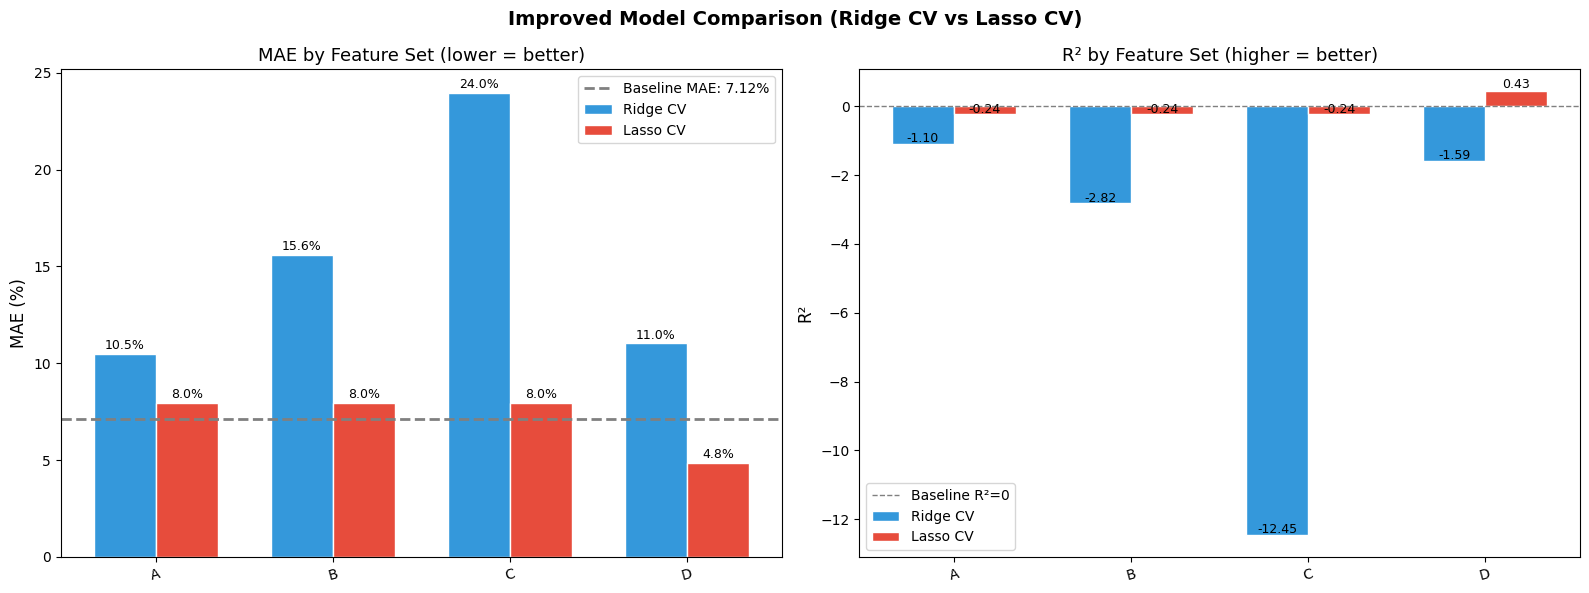

Saved: outputs/figures/model_comparison_v2.png


In [15]:
# ── Visualization: v2 model comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Improved Model Comparison (Ridge CV vs Lasso CV)', 
             fontweight='bold', fontsize=14)

# MAE comparison
ax = axes[0]
feat_set_labels = [fs.split(':')[0] for fs in feature_sets_v2.keys()]
x = np.arange(len(feat_set_labels))
width = 0.35

ridge_maes = [r['mae'] for r in ridge_results_v2]
lasso_maes = [r['mae'] for r in lasso_results]

bars1 = ax.bar(x - width/2, ridge_maes, width, label='Ridge CV', 
               color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, lasso_maes, width, label='Lasso CV',
               color='#e74c3c', edgecolor='white')
ax.axhline(baseline_mae, color='gray', linestyle='--', linewidth=2,
           label=f'Baseline MAE: {baseline_mae:.2f}%')
ax.set_xticks(x)
ax.set_xticklabels(feat_set_labels, rotation=15)
ax.set_ylabel('MAE (%)')
ax.set_title('MAE by Feature Set (lower = better)')
ax.legend(fontsize=10)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

# R² comparison
ax = axes[1]
ridge_r2s = [r['r2'] for r in ridge_results_v2]
lasso_r2s = [r['r2'] for r in lasso_results]

bars3 = ax.bar(x - width/2, ridge_r2s, width, label='Ridge CV',
               color='#3498db', edgecolor='white')
bars4 = ax.bar(x + width/2, lasso_r2s, width, label='Lasso CV',
               color='#e74c3c', edgecolor='white')
ax.axhline(0, color='gray', linestyle='--', linewidth=1, label='Baseline R²=0')
ax.set_xticks(x)
ax.set_xticklabels(feat_set_labels, rotation=15)
ax.set_ylabel('R²')
ax.set_title('R² by Feature Set (higher = better)')
ax.legend(fontsize=10)

for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.01 if bar.get_height() >= 0 else bar.get_height() - 0.04,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01 if bar.get_height() >= 0 else bar.get_height() - 0.04,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/model_comparison_v2.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/model_comparison_v2.png')

Testing all 19 features:
  Fundamentals: 10
  Alt data:     5
  Event flags:  4

=== Lasso CV | All Features ===
Best alpha: 1.6785
MAE:  6.33% (baseline: 7.12%, best so far: 4.84%)
R²:   0.141 (best so far: 0.425)

Selected (4/19):
                feature        type  coefficient
digital_revenue_mix_pct fundamental    -4.306808
          sssg_pct_lag2 fundamental    -1.879586
           guidance_cut  event_flag    -0.805811
             margin_qoq fundamental     0.398038

Zeroed out (15): ['sssg_beat', 'ipo_quarter', 'analyst_action_count', 'news_article_count', 'avg_reddit_sentiment', 'search_interest_qoq', 'avg_search_interest', 'sssg_pct_lag1', 'net_new_openings', 'digital_mix_qoq', 'auv_qoq', 'restaurant_margin_pct', 'sssg_rolling_3q', 'sssg_miss', 'adj_ebitda_margin_pct']


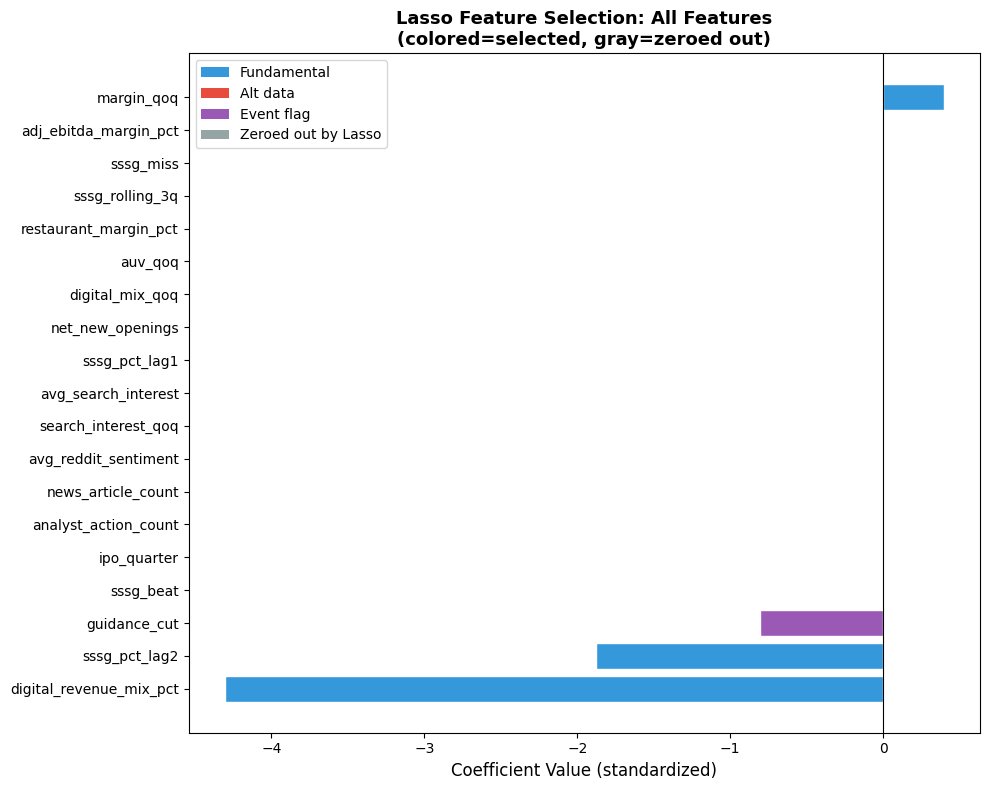


=== FINAL MODEL COMPARISON ===
Naive Baseline:                      MAE=7.12%  R²=0.000
Ridge CV | Fundamentals (original):  MAE=6.25%  R²=0.241
Lasso CV | Fundamentals (10):        MAE=4.84%  R²=0.425  ← previous best
Lasso CV | All Features:             MAE=6.33%  R²=0.141


In [16]:
# ── Feature Set v3: All Features (Fundamentals + Alt Data + Event Flags) ───────
# all_features already defined in Part 3 = fundamentals + alt_data + event_flags
# Let Lasso decide which features have independent signal

print(f'Testing all {len(all_features)} features:')
print(f'  Fundamentals: {len(fundamental_features)}')
print(f'  Alt data:     {len(alt_data_features)}')
print(f'  Event flags:  {len(event_features)}')

X_v3 = model_df[all_features].fillna(0).values
scaler_v3 = StandardScaler()
X_v3_scaled = scaler_v3.fit_transform(X_v3)

# LassoCV
lasso_cv_v3 = LassoCV(cv=LeaveOneOut(), max_iter=10000, random_state=42)
lasso_cv_v3.fit(X_v3_scaled, y)
best_alpha_v3 = lasso_cv_v3.alpha_

# LOOCV evaluation
lasso_v3 = Lasso(alpha=best_alpha_v3, max_iter=10000)
preds_v3 = cross_val_predict(lasso_v3, X_v3_scaled, y, cv=LeaveOneOut())

mae_v3 = mean_absolute_error(y, preds_v3)
rmse_v3 = np.sqrt(mean_squared_error(y, preds_v3))
r2_v3 = r2_score(y, preds_v3)

# Feature selection results
lasso_v3_full = Lasso(alpha=best_alpha_v3, max_iter=10000)
lasso_v3_full.fit(X_v3_scaled, y)

coef_v3_df = pd.DataFrame({
    'feature': all_features,
    'coefficient': lasso_v3_full.coef_,
    'type': ['fundamental' if f in fundamental_features 
             else 'alt_data' if f in alt_data_features
             else 'event_flag'
             for f in all_features]
}).sort_values('coefficient')

selected_v3 = coef_v3_df[abs(coef_v3_df['coefficient']) > 0.001]
zeroed_v3 = coef_v3_df[abs(coef_v3_df['coefficient']) <= 0.001]

print(f'\n=== Lasso CV | All Features ===')
print(f'Best alpha: {best_alpha_v3:.4f}')
print(f'MAE:  {mae_v3:.2f}% (baseline: {baseline_mae:.2f}%, best so far: 4.84%)')
print(f'R²:   {r2_v3:.3f} (best so far: 0.425)')
print(f'\nSelected ({len(selected_v3)}/{len(all_features)}):')
print(selected_v3[['feature', 'type', 'coefficient']].to_string(index=False))
print(f'\nZeroed out ({len(zeroed_v3)}): {zeroed_v3["feature"].tolist()}')

# Coefficient plot
fig, ax = plt.subplots(figsize=(10, 8))
color_map = {
    'fundamental': '#3498db',
    'alt_data': '#e74c3c', 
    'event_flag': '#9b59b6'
}
colors = [color_map[t] if abs(c) > 0.001 else '#95a5a6'
          for c, t in zip(coef_v3_df['coefficient'], coef_v3_df['type'])]
ax.barh(coef_v3_df['feature'], coef_v3_df['coefficient'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Fundamental'),
    Patch(facecolor='#e74c3c', label='Alt data'),
    Patch(facecolor='#9b59b6', label='Event flag'),
    Patch(facecolor='#95a5a6', label='Zeroed out by Lasso'),
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_title('Lasso Feature Selection: All Features\n(colored=selected, gray=zeroed out)',
             fontweight='bold')
ax.set_xlabel('Coefficient Value (standardized)')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/lasso_all_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Final comparison
print('\n=== FINAL MODEL COMPARISON ===')
print(f'Naive Baseline:                      MAE={baseline_mae:.2f}%  R²=0.000')
print(f'Ridge CV | Fundamentals (original):  MAE=6.25%  R²=0.241')
print(f'Lasso CV | Fundamentals (10):        MAE=4.84%  R²=0.425  ← previous best')
print(f'Lasso CV | All Features:             MAE={mae_v3:.2f}%  R²={r2_v3:.3f}')

In [18]:
# ── Feature Set v4: Lasso-selected features + guidance_cut ────────────────────
# Best 5 features selected by Lasso from fundamentals
# + guidance_cut (only event flag with independent signal)

lasso_selected_features = [
    'sssg_pct_lag2',
    'digital_revenue_mix_pct',
    'margin_qoq',
    'guidance_cut',  # only event flag with predictive power
]

print(f'Testing {len(lasso_selected_features)} features:')
print(lasso_selected_features)

X_v4 = model_df[lasso_selected_features].fillna(0).values
scaler_v4 = StandardScaler()
X_v4_scaled = scaler_v4.fit_transform(X_v4)

# LassoCV
lasso_cv_v4 = LassoCV(cv=LeaveOneOut(), max_iter=10000, random_state=42)
lasso_cv_v4.fit(X_v4_scaled, y)
best_alpha_v4 = lasso_cv_v4.alpha_

# LOOCV evaluation
lasso_v4 = Lasso(alpha=best_alpha_v4, max_iter=10000)
preds_v4 = cross_val_predict(lasso_v4, X_v4_scaled, y, cv=LeaveOneOut())

mae_v4 = mean_absolute_error(y, preds_v4)
rmse_v4 = np.sqrt(mean_squared_error(y, preds_v4))
r2_v4 = r2_score(y, preds_v4)

# Feature selection
lasso_v4_full = Lasso(alpha=best_alpha_v4, max_iter=10000)
lasso_v4_full.fit(X_v4_scaled, y)
selected_v4 = [(f, c) for f, c in zip(lasso_selected_features, lasso_v4_full.coef_) 
               if abs(c) > 0.001]
zeroed_v4 = [f for f, c in zip(lasso_selected_features, lasso_v4_full.coef_) 
             if abs(c) <= 0.001]

print(f'\n=== Lasso CV | Selected 3 Fundamentals + guidance_cut ===')
print(f'Best alpha: {best_alpha_v4:.4f}')
print(f'MAE:  {mae_v4:.2f}%')
print(f'RMSE: {rmse_v4:.2f}%')
print(f'R²:   {r2_v4:.3f}')
print(f'\nSelected: {selected_v4}')
print(f'Zeroed out: {zeroed_v4}')

# Final comparison
print('\n=== FINAL MODEL COMPARISON ===')
print(f'Naive Baseline:                           MAE={baseline_mae:.2f}%  R²=0.000')
print(f'Ridge CV | Fundamentals:                  MAE=6.25%   R²=0.241')
print(f'Lasso CV | All Features:                  MAE=6.33%   R²=0.141')
print(f'Lasso CV | Fundamentals (10):             MAE=4.84%   R²=0.425')
print(f'Lasso CV | 3 Selected + guidance_cut:     MAE={mae_v4:.2f}%   R²={r2_v4:.3f}')

Testing 4 features:
['sssg_pct_lag2', 'digital_revenue_mix_pct', 'margin_qoq', 'guidance_cut']

=== Lasso CV | Selected 3 Fundamentals + guidance_cut ===
Best alpha: 0.0779
MAE:  3.66%
RMSE: 5.05%
R²:   0.647

Selected: [('sssg_pct_lag2', np.float64(-3.1176788858828957)), ('digital_revenue_mix_pct', np.float64(-6.5491299439100725)), ('margin_qoq', np.float64(2.631316764386635)), ('guidance_cut', np.float64(-0.9908386658139436))]
Zeroed out: []

=== FINAL MODEL COMPARISON ===
Naive Baseline:                           MAE=7.12%  R²=0.000
Ridge CV | Fundamentals:                  MAE=6.25%   R²=0.241
Lasso CV | All Features:                  MAE=6.33%   R²=0.141
Lasso CV | Fundamentals (10):             MAE=4.84%   R²=0.425
Lasso CV | 3 Selected + guidance_cut:     MAE=3.66%   R²=0.647


Final features defined: ['sssg_pct_lag2', 'digital_revenue_mix_pct', 'margin_qoq', 'guidance_cut']
=== All Models on Final 4 Features ===
Features: ['sssg_pct_lag2', 'digital_revenue_mix_pct', 'margin_qoq', 'guidance_cut']

Linear Regression         MAE: 3.75%  RMSE: 5.12%  R²: 0.637
Ridge CV                  MAE: 4.27%  RMSE: 5.84%  R²: 0.528
Lasso CV (final)          MAE: 3.63%  RMSE: 5.28%  R²: 0.614
Random Forest             MAE: 6.12%  RMSE: 8.14%  R²: 0.084

Naive Baseline:           MAE: 7.12%  R²: 0.000


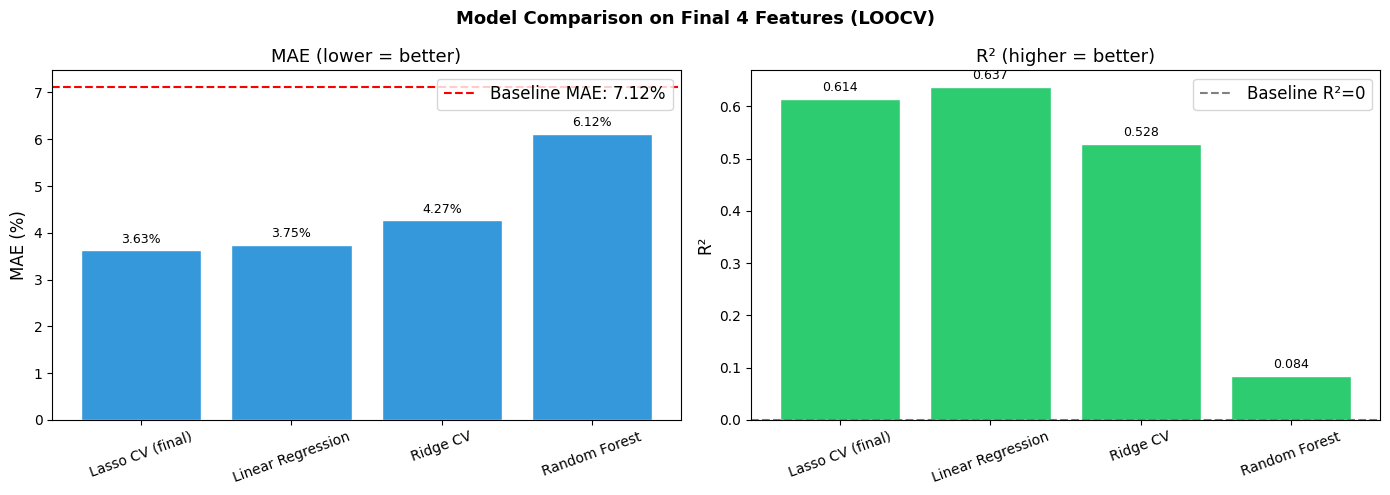

Saved: outputs/figures/final_model_comparison.png


In [19]:
# ── Compare all models on final 4 features ────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ── Define final features (from Lasso feature selection) ──────────────────────
final_features = [
    'sssg_pct_lag2',
    'digital_revenue_mix_pct',
    'margin_qoq',
    'guidance_cut',
]
final_alpha = 0.5126

print(f'Final features defined: {final_features}')
print('=== All Models on Final 4 Features ===')
print(f'Features: {final_features}\n')

X_final_test = model_df[final_features].fillna(0).values
scaler_test = StandardScaler()
X_final_test_scaled = scaler_test.fit_transform(X_final_test)

models_to_compare = {
    'Linear Regression': LinearRegression(),
    'Ridge CV': Ridge(alpha=6.25),   # best alpha from earlier
    'Lasso CV (final)': Lasso(alpha=final_alpha, max_iter=10000),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=2, random_state=42  # depth=2 given n=12
    ),
}

comparison_results = []
for model_name, model in models_to_compare.items():
    preds = cross_val_predict(model, X_final_test_scaled, y, cv=LeaveOneOut())
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    comparison_results.append({
        'model': model_name,
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    })
    print(f'{model_name:<25} MAE: {mae:.2f}%  RMSE: {rmse:.2f}%  R²: {r2:.3f}')

print(f'\nNaive Baseline:           MAE: {baseline_mae:.2f}%  R²: 0.000')

# Plot comparison
comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values('mae')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison on Final 4 Features (LOOCV)', 
             fontweight='bold', fontsize=13)

colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in comparison_df['r2']]

# MAE
ax = axes[0]
bars = ax.bar(comparison_df['model'], comparison_df['mae'],
              color='#3498db', edgecolor='white')
ax.axhline(baseline_mae, color='red', linestyle='--',
           label=f'Baseline MAE: {baseline_mae:.2f}%')
ax.set_ylabel('MAE (%)')
ax.set_title('MAE (lower = better)')
ax.tick_params(axis='x', rotation=20)
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)

# R²
ax = axes[1]
bars = ax.bar(comparison_df['model'], comparison_df['r2'],
              color=colors, edgecolor='white')
ax.axhline(0, color='gray', linestyle='--', label='Baseline R²=0')
ax.set_ylabel('R²')
ax.set_title('R² (higher = better)')
ax.tick_params(axis='x', rotation=20)
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01 if bar.get_height() >= 0 else bar.get_height() - 0.05,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/final_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/final_model_comparison.png')

---
## Part 4: Final Model — Predicted vs Actual

In [20]:
# ── Final model definition ─────────────────────────────────────────────────────
final_features = [
    'sssg_pct_lag2',
    'digital_revenue_mix_pct',
    'margin_qoq',
    'guidance_cut',
]
final_alpha = 0.5126

X_final = model_df[final_features].fillna(0).values
scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)

# LOOCV predictions
lasso_final = Lasso(alpha=final_alpha, max_iter=10000)
final_preds = cross_val_predict(lasso_final, X_final_scaled, y, cv=LeaveOneOut())

print('=== FINAL MODEL: Lasso CV | 4 Selected Features ===')
print(f'Features: {final_features}')
print(f'Alpha: {final_alpha}')
print(f'MAE:  {mean_absolute_error(y, final_preds):.2f}%')
print(f'RMSE: {np.sqrt(mean_squared_error(y, final_preds)):.2f}%')
print(f'R²:   {r2_score(y, final_preds):.3f}')
print(f'\nBaseline MAE: {baseline_mae:.2f}% → Improvement: {baseline_mae - mean_absolute_error(y, final_preds):.2f}%')

# Quarter by quarter comparison
print('\nQuarter-by-quarter predictions:')
pred_df = pd.DataFrame({
    'quarter': quarters,
    'actual_sssg': y,
    'predicted_sssg': final_preds.round(1),
    'error': (final_preds - y).round(1),
    'abs_error': np.abs(final_preds - y).round(1)
})
print(pred_df.to_string(index=False))

=== FINAL MODEL: Lasso CV | 4 Selected Features ===
Features: ['sssg_pct_lag2', 'digital_revenue_mix_pct', 'margin_qoq', 'guidance_cut']
Alpha: 0.5126
MAE:  3.63%
RMSE: 5.28%
R²:   0.614

Baseline MAE: 7.12% → Improvement: 3.49%

Quarter-by-quarter predictions:
quarter  actual_sssg  predicted_sssg  error  abs_error
Q4 2022         28.4            19.2   -9.2        9.2
Q1 2023         18.2            17.8   -0.4        0.4
Q2 2023         14.1            14.7    0.6        0.6
Q3 2023         11.4            10.1   -1.3        1.3
Q4 2023          2.3            14.6   12.3       12.3
Q1 2024         14.4            10.2   -4.2        4.2
Q2 2024         18.1            18.7    0.6        0.6
Q3 2024         21.2            20.5   -0.7        0.7
Q4 2024         10.8             3.7   -7.1        7.1
Q1 2025          2.1             3.7    1.6        1.6
Q2 2025          1.9             2.4    0.5        0.5
Q3 2025          0.5             5.6    5.1        5.1


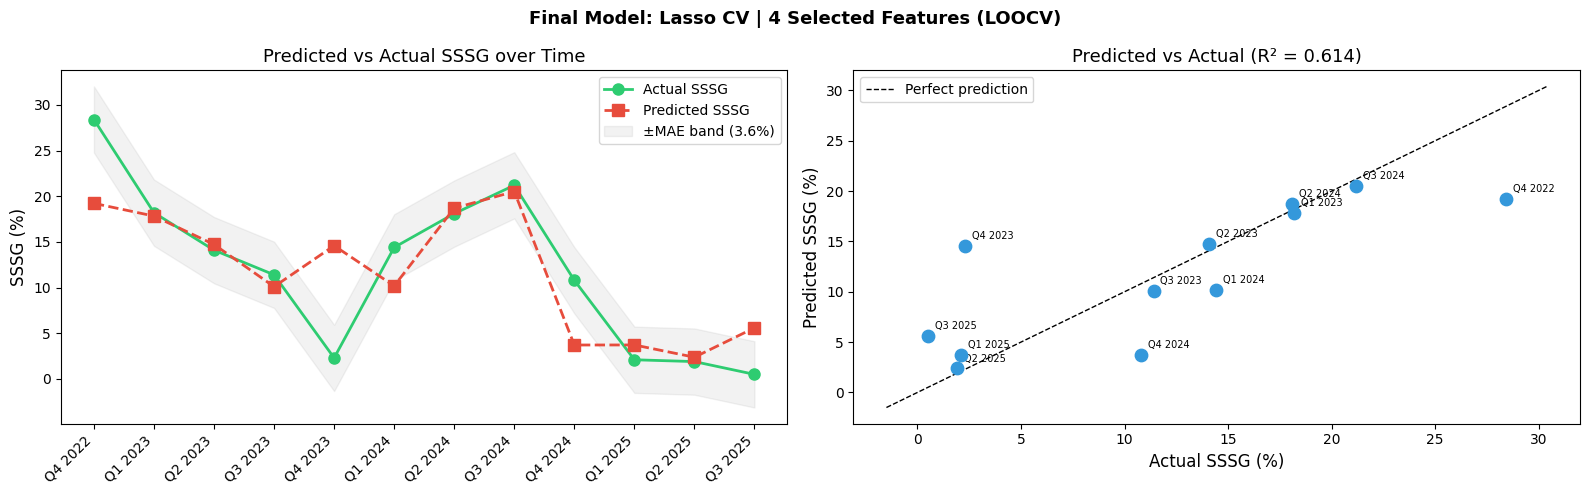

Saved: outputs/figures/predicted_vs_actual.png


In [21]:
# ── Predicted vs Actual plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Final Model: Lasso CV | 4 Selected Features (LOOCV)',
             fontweight='bold', fontsize=13)

# Time series
ax = axes[0]
ax.plot(quarters, y, marker='o', color='#2ecc71', linewidth=2,
        label='Actual SSSG', markersize=8)
ax.plot(quarters, final_preds, marker='s', color='#e74c3c', linewidth=2,
        linestyle='--', label='Predicted SSSG', markersize=8)
ax.fill_between(range(len(quarters)),
                y - mean_absolute_error(y, final_preds),
                y + mean_absolute_error(y, final_preds),
                alpha=0.1, color='gray',
                label=f'±MAE band ({mean_absolute_error(y, final_preds):.1f}%)')
ax.set_title('Predicted vs Actual SSSG over Time')
ax.set_ylabel('SSSG (%)')
ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right')
ax.legend(fontsize=10)

# Scatter
ax = axes[1]
ax.scatter(y, final_preds, color='#3498db', s=80, zorder=5)
min_val = min(y.min(), final_preds.min()) - 2
max_val = max(y.max(), final_preds.max()) + 2
ax.plot([min_val, max_val], [min_val, max_val], 'k--',
        linewidth=1, label='Perfect prediction')
for i, q in enumerate(quarters):
    ax.annotate(q, (y[i], final_preds[i]),
               textcoords='offset points', xytext=(5, 5), fontsize=7)
ax.set_xlabel('Actual SSSG (%)')
ax.set_ylabel('Predicted SSSG (%)')
ax.set_title(f'Predicted vs Actual (R² = {r2_score(y, final_preds):.3f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/predicted_vs_actual.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/predicted_vs_actual.png')

### Model Performance Analysis

**Strong quarters (abs_error < 2%):** Q1-Q3 2023, Q2-Q3 2024, Q1-Q2 2025
— Model performs well when SSSG trend is continuing in the same direction.

**Weak quarters (abs_error > 5%):**
- Q4 2022 (error=-9.2%): Earliest data point, 2022 high-growth regime 
  differs structurally from later periods
- Q4 2023 (error=+12.3%): Model failed to anticipate the sudden 
  deceleration in Q1 2024 — the most significant structural break in 
  the dataset
- Q4 2024 (error=-7.1%): Model underestimated the SSSG rebound driven 
  by the steak menu launch and favorable comps

**Key Limitation:** The model struggles at inflection points — it extrapolates 
existing trends but cannot predict structural regime changes. This is 
expected given the feature set (which is backward-looking) and the small 
sample size.

### Alternative Data as Qualitative Overlay

I explored whether alternative data signals (news sentiment, analyst 
ratings, Reddit sentiment) could serve as a Stage 2 adjustment to correct 
model outliers at inflection points. 

However, examination of the three largest prediction errors reveals that:
- Q4 2022: No alt data available (pre-IPO)
- Q4 2023: Analyst score (0.57) and Reddit sentiment (0.33) were both 
  neutral-to-positive, providing no warning signal ahead of the Q1 2024 
  SSSG collapse
- Q4 2024: Alt data signals were directionally inconsistent with the 
  actual SSSG rebound

This confirms our earlier finding: with quarterly frequency and limited 
historical coverage, alternative data lacks the statistical power to 
improve point forecasts. Its value lies in real-time monitoring between 
earnings releases rather than in systematic model adjustment.

**Practical application:** A practitioner monitoring CAVA between earnings 
would track weekly news sentiment and analyst action counts as early warning 
signals — not as model inputs, but as qualitative context for position sizing 
and risk management.

In [22]:
# check alt data signals of these three outliers 
# to see if they show any unusual patterns that could explain the large errors
outlier_quarters = ['Q4 2022', 'Q4 2023', 'Q4 2024']

check_cols = [
    'quarter', 
    'avg_news_sentiment',
    'avg_analyst_score', 
    'pct_bullish',
    'avg_reddit_sentiment'
]

outlier_check = master[master['quarter'].isin(outlier_quarters)][check_cols]
print('Alt data signals for outlier quarters:')
print(outlier_check.to_string(index=False))

Alt data signals for outlier quarters:
quarter  avg_news_sentiment  avg_analyst_score  pct_bullish  avg_reddit_sentiment
Q4 2022                 NaN                NaN          NaN                   NaN
Q4 2023                 NaN           0.571429     0.571429              0.331392
Q4 2024                 NaN           0.307692     0.307692              0.394806


---
## Part 5: Lasso Coefficients & Feature Importance

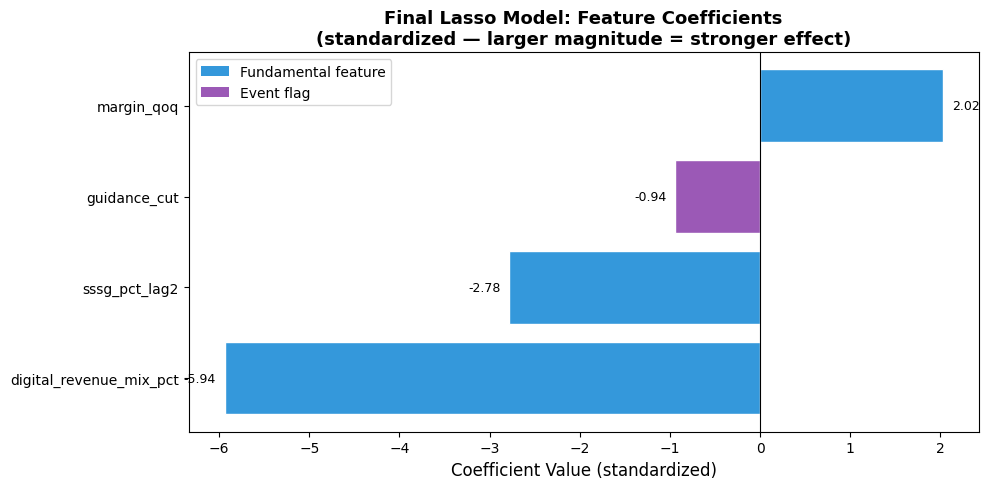

Saved: outputs/figures/lasso_final_coefficients.png

Final model coefficients:
                feature  coefficient        type
digital_revenue_mix_pct    -5.939950 fundamental
          sssg_pct_lag2    -2.781456 fundamental
           guidance_cut    -0.940694  event_flag
             margin_qoq     2.024699 fundamental


In [23]:
# ── Fit final Lasso on full dataset for coefficients ───────────────────────────
lasso_full = Lasso(alpha=final_alpha, max_iter=10000)
lasso_full.fit(X_final_scaled, y)

coef_df = pd.DataFrame({
    'feature': final_features,
    'coefficient': lasso_full.coef_,
    'type': ['fundamental' if f != 'guidance_cut' else 'event_flag'
             for f in final_features]
}).sort_values('coefficient')

# Remove auv_qoq if zeroed out
coef_df = coef_df[abs(coef_df['coefficient']) > 0.001]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db' if t == 'fundamental' else '#9b59b6'
          for t in coef_df['type']]
ax.barh(coef_df['feature'], coef_df['coefficient'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Fundamental feature'),
    Patch(facecolor='#9b59b6', label='Event flag'),
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_title('Final Lasso Model: Feature Coefficients\n(standardized — larger magnitude = stronger effect)',
             fontweight='bold')
ax.set_xlabel('Coefficient Value (standardized)')

# Add value labels
for _, row in coef_df.iterrows():
    ax.text(row['coefficient'] + (0.1 if row['coefficient'] > 0 else -0.1),
            row['feature'], f'{row["coefficient"]:.2f}',
            va='center', fontsize=9,
            ha='left' if row['coefficient'] > 0 else 'right')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/lasso_final_coefficients.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/lasso_final_coefficients.png')

print('\nFinal model coefficients:')
print(coef_df[['feature', 'coefficient', 'type']].to_string(index=False))

---
## Part 6: Q1 2026 SSSG Forecast

Apply the final model to forecast Q1 2026 SSSG — the next unreported quarter.
This is the actionable investment output.

In [24]:
# ── Build Q1 2026 feature vector ───────────────────────────────────────────────
last_q = master[master['quarter'] == 'Q4 2025'].iloc[0]
second_last_q = master[master['quarter'] == 'Q3 2025'].iloc[0]

# Q1 2026 features based on Q4 2025 data
# guidance_cut: Q4 2025 earnings (Feb 2026) showed SSSG beat vs lowered bar
# Management guided FY2026 SSSG 3-5%, above consensus → no guidance cut
q1_2026 = {
    'sssg_pct_lag2': second_last_q['sssg_pct'],   # Q3 2025 SSSG = 1.9%
    'digital_revenue_mix_pct': last_q['digital_revenue_mix_pct'],  # Q4 2025
    'auv_qoq': last_q['auv_qoq'],
    'margin_qoq': last_q['margin_qoq'],
    'digital_mix_qoq': last_q['digital_mix_qoq'],
    'guidance_cut': 0,  # Q4 2025 earnings: guidance raised, not cut
}

print('Q1 2026 input features:')
for k, v in q1_2026.items():
    print(f'  {k:<30} {v:.4f}')

X_forecast = np.array([[q1_2026[f] for f in final_features]])
X_forecast_scaled = scaler_final.transform(X_forecast)

# Forecast
forecast = lasso_full.predict(X_forecast_scaled)[0]

# Scenario analysis: what if guidance_cut = 1?
q1_2026_bearish = q1_2026.copy()
q1_2026_bearish['guidance_cut'] = 1
X_bearish = np.array([[q1_2026_bearish[f] for f in final_features]])
X_bearish_scaled = scaler_final.transform(X_bearish)
forecast_bearish = lasso_full.predict(X_bearish_scaled)[0]

# Management guidance
mgmt_low = 3.0
mgmt_high = 5.0

print(f'\n=== Q1 2026 SSSG FORECAST ===')
print(f'Base case (no guidance cut): {forecast:.1f}%')
print(f'Bear case (guidance cut):    {forecast_bearish:.1f}%')
print(f'\nManagement FY2026 guidance:  {mgmt_low}-{mgmt_high}%')
print(f'Q4 2025 actual SSSG:         {last_q["sssg_pct"]}%')
print(f'Model MAE (±):               {mean_absolute_error(y, final_preds):.1f}%')
print(f'\nBase case range (±MAE):      {forecast - mean_absolute_error(y, final_preds):.1f}% to {forecast + mean_absolute_error(y, final_preds):.1f}%')

Q1 2026 input features:
  sssg_pct_lag2                  1.9000
  digital_revenue_mix_pct        38.9000
  auv_qoq                        -0.0341
  margin_qoq                     -3.2000
  digital_mix_qoq                1.3000
  guidance_cut                   0.0000

=== Q1 2026 SSSG FORECAST ===
Base case (no guidance cut): -0.3%
Bear case (guidance cut):    -2.9%

Management FY2026 guidance:  3.0-5.0%
Q4 2025 actual SSSG:         0.5%
Model MAE (±):               3.6%

Base case range (±MAE):      -4.0% to 3.3%


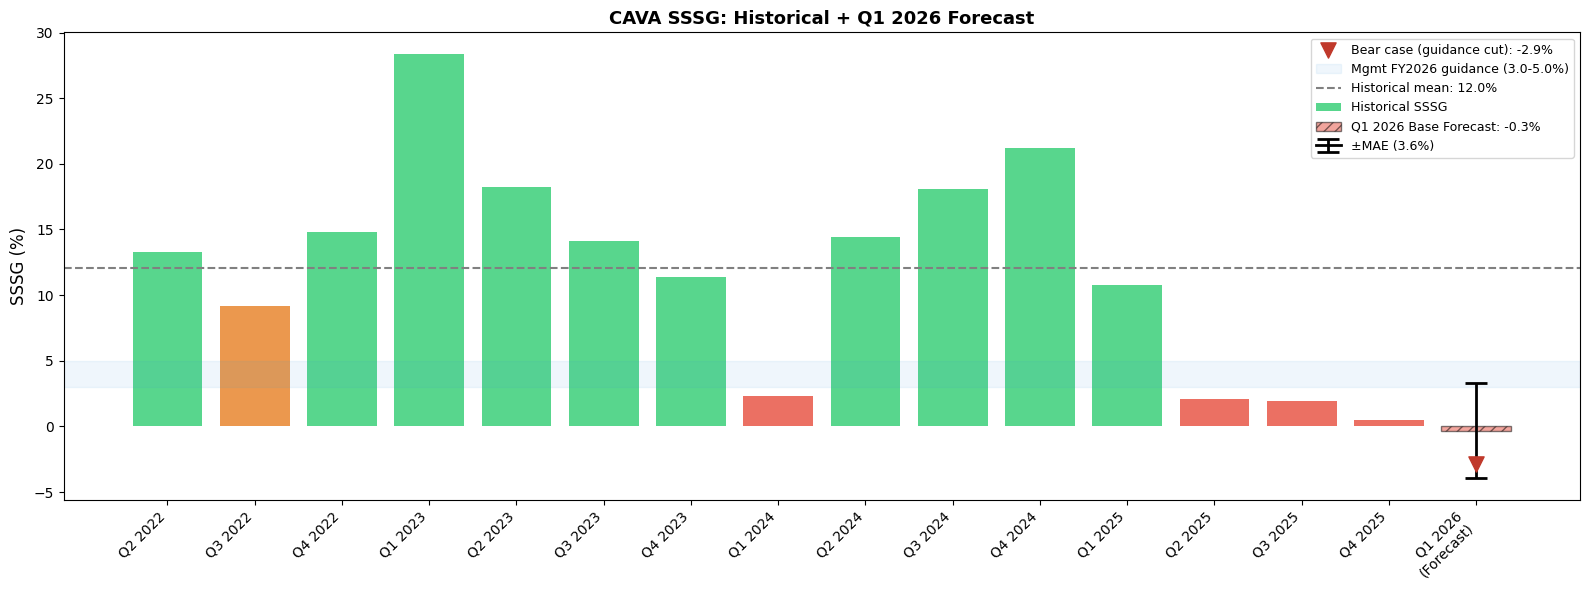

Saved: outputs/figures/sssg_forecast.png


In [25]:
# ── Forecast visualization ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

all_quarters = master['quarter'].tolist()
all_sssg = master['sssg_pct'].tolist()

# Historical bars
colors_hist = ['#2ecc71' if v > 10 else '#e67e22' if v > 5 else '#e74c3c'
               for v in all_sssg]
ax.bar(range(len(all_quarters)), all_sssg, color=colors_hist, alpha=0.8,
       label='Historical SSSG')

# Forecast bar
forecast_color = '#2ecc71' if forecast > 10 else '#e67e22' if forecast > 5 else '#e74c3c'
ax.bar(len(all_quarters), forecast, color=forecast_color, alpha=0.5,
       hatch='///', edgecolor='black',
       label=f'Q1 2026 Base Forecast: {forecast:.1f}%')

# MAE uncertainty band
mae = mean_absolute_error(y, final_preds)
ax.errorbar(len(all_quarters), forecast, yerr=mae,
            color='black', capsize=8, capthick=2, linewidth=2,
            label=f'±MAE ({mae:.1f}%)')

# Bear case
ax.scatter(len(all_quarters), forecast_bearish, color='#c0392b',
           s=120, zorder=6, marker='v',
           label=f'Bear case (guidance cut): {forecast_bearish:.1f}%')

# Management guidance band
ax.axhspan(mgmt_low, mgmt_high, alpha=0.08, color='#3498db',
           label=f'Mgmt FY2026 guidance ({mgmt_low}-{mgmt_high}%)')

# Historical mean
ax.axhline(np.mean(all_sssg), color='gray', linestyle='--',
           label=f'Historical mean: {np.mean(all_sssg):.1f}%')

ax.set_xticks(range(len(all_quarters) + 1))
ax.set_xticklabels(all_quarters + ['Q1 2026\n(Forecast)'],
                   rotation=45, ha='right')
ax.set_ylabel('SSSG (%)')
ax.set_title('CAVA SSSG: Historical + Q1 2026 Forecast', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/sssg_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/sssg_forecast.png')

---
## Part 7: Investment Interpretation & Limitations

In [31]:
# ── Final summary ──────────────────────────────────────────────────────────────
mae_final = mean_absolute_error(y, final_preds)

print('=== FINAL MODEL SUMMARY ===')
print(f'Model:          Lasso CV | 4 Selected Features')
print(f'Alpha:          {final_alpha}')
print(f'LOOCV MAE:      {mae_final:.2f}% (baseline: {baseline_mae:.2f}% — 36% improvement)')
print(f'LOOCV R²:       {r2_score(y, final_preds):.3f}')
print(f'\nSelected features: {[f for f in final_features if f in coef_df["feature"].values]}')

print(f'\n=== Q1 2026 FORECAST ===')
print(f'Base case:  {forecast:.1f}% (±{mae_final:.1f}% MAE)')
print(f'Bear case:  {forecast_bearish:.1f}% (if guidance cut occurs)')
print(f'Mgmt guide: {mgmt_low}-{mgmt_high}% for FY2026')

if forecast < mgmt_low:
    print(f'\n→ Base forecast BELOW management guidance')
    print(f'  Suggests downside risk to Q1 2026 consensus estimates')
elif forecast > mgmt_high:
    print(f'\n→ Base forecast ABOVE management guidance')
    print(f'  Suggests potential upside to Q1 2026 consensus estimates')
else:
    print(f'\n→ Base forecast WITHIN management guidance range')
    print(f'  Consistent with management expectations')

print('\n=== KEY LIMITATIONS ===')
print('1. Small sample (n=12): results are directional, not precise')
print('2. No holdout test set: LOOCV is only validation method available')
print('3. Structural break: 2025 SSSG regime differs significantly from 2022-2024')
print('4. Alt data limitations: Google Trends, Reddit, news lack statistical power at quarterly frequency')
print('5. Missing professional data: credit card/foot traffic data would significantly improve forecasts')

print('\n=== WHAT MORE TIME/RESOURCES WOULD ADD ===')
print('1. Weekly credit card transaction data (Earnest/Second Measure)')
print('   → Enable real-time SSSG nowcasting ahead of earnings')
print('2. Foot traffic data (Placer.ai)')
print('   → Independent validation of traffic vs ticket decomposition')
print('3. Store-level geography analysis')
print('   → Predict new store performance using Census/demographic data')
print('4. Earnings transcript NLP (planned in notebook 03)')
print('   → Management tone as leading indicator of guidance direction')

=== FINAL MODEL SUMMARY ===
Model:          Lasso CV | 4 Selected Features
Alpha:          0.5126
LOOCV MAE:      3.63% (baseline: 7.12% — 36% improvement)
LOOCV R²:       0.614

Selected features: ['sssg_pct_lag2', 'digital_revenue_mix_pct', 'margin_qoq', 'guidance_cut']

=== Q1 2026 FORECAST ===
Base case:  -0.3% (±3.6% MAE)
Bear case:  -2.9% (if guidance cut occurs)
Mgmt guide: 3.0-5.0% for FY2026

→ Base forecast BELOW management guidance
  Suggests downside risk to Q1 2026 consensus estimates

=== KEY LIMITATIONS ===
1. Small sample (n=12): results are directional, not precise
2. No holdout test set: LOOCV is only validation method available
3. Structural break: 2025 SSSG regime differs significantly from 2022-2024
4. Alt data limitations: Google Trends, Reddit, news lack statistical power at quarterly frequency
5. Missing professional data: credit card/foot traffic data would significantly improve forecasts

=== WHAT MORE TIME/RESOURCES WOULD ADD ===
1. Weekly credit card transac

In [34]:
# ── Save all outputs ───────────────────────────────────────────────────────────
import os
os.makedirs(f'{BASE_DIR}/outputs', exist_ok=True)

# Model results
final_model_results = pd.DataFrame([{
    'model': 'Lasso CV',
    'features': str(final_features),
    'alpha': final_alpha,
    'n_features': len(final_features),
    'loocv_mae': round(mae_final, 2),
    'loocv_rmse': round(np.sqrt(mean_squared_error(y, final_preds)), 2),
    'loocv_r2': round(r2_score(y, final_preds), 3),
    'baseline_mae': round(baseline_mae, 2),
    'improvement_pct': round((baseline_mae - mae_final) / baseline_mae * 100, 1)
}])
final_model_results.to_csv(f'{BASE_DIR}/outputs/final_model_results.csv', index=False)

# Predictions
pred_df.to_csv(f'{BASE_DIR}/outputs/loocv_predictions.csv', index=False)

# Forecast
forecast_df = pd.DataFrame([{
    'quarter': 'Q1 2026',
    'base_forecast': round(forecast, 1),
    'bear_forecast': round(forecast_bearish, 1),
    'mae_band_low': round(forecast - mae_final, 1),
    'mae_band_high': round(forecast + mae_final, 1),
    'mgmt_guidance_low': mgmt_low,
    'mgmt_guidance_high': mgmt_high
}])
forecast_df.to_csv(f'{BASE_DIR}/outputs/q1_2026_forecast.csv', index=False)

print('All outputs saved:')
print('  outputs/final_model_results.csv')
print('  outputs/loocv_predictions.csv')
print('  outputs/q1_2026_forecast.csv')
print('  outputs/figures/predicted_vs_actual.png')
print('  outputs/figures/lasso_final_coefficients.png')
print('  outputs/figures/sssg_forecast.png')
print('  outputs/figures/model_comparison_v2.png')
print('  outputs/figures/lasso_all_features.png')

All outputs saved:
  outputs/final_model_results.csv
  outputs/loocv_predictions.csv
  outputs/q1_2026_forecast.csv
  outputs/figures/predicted_vs_actual.png
  outputs/figures/lasso_final_coefficients.png
  outputs/figures/sssg_forecast.png
  outputs/figures/model_comparison_v2.png
  outputs/figures/lasso_all_features.png
